# Preprocessing steps for the Xray data
 1. Load the data
 2. Resize the images 224x224
 3. Resize bounding boxes - Note this is already done for this dataset
 4. Standardize the images into a 0-1 range (divide by 255 for xray images)
 5. Split dataset into 4000 training images and 96 validation images
 6. Compute training mean and standard deviation for normalization


# Dataset
- Task: Given a subject idx, load the corresponding X-ray image and bounding box coordinates(Xmin, Ymin, Xmax, Ymax)
- Z-normalize the image with computed mean and standard deviation
## $$ x_{norm} = \frac{x-\mu}{\sigma}$$

# Apply Data Augmentation:
- Gamma (Contrast Changes(0.7, 1.7))
- Scaling (0.8, 1.2)
- Rotation (-10, 10) [deg]
- Translation (-10px, 10px)

#### Apply Same agmentation to the bounding box corrdinates


# Training
- ResNet18
-- change input channel from 3 to 1 (only one channel for X-ray images)
-- change output dimesion from 1000 to 4 to repersent the bounding box 4 courners for heart detection

- Loss Function - Mean Squared Error
- Optimzer - Adam (lr=1e-4)
-Train for 50 epochs


In [11]:
from pathlib import Path
import pydicom
import numpy as np
import cv2
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
import itertools

import torch
import torchvision
from torchvision import transforms
import torchmetrics
import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint
from pytorch_lightning.loggers import TensorBoardLogger
from tqdm.notebook import tqdm
from PIL import Image
import random


# Load Data

In [7]:
labels = pd.read_csv('../DATA/05-Detection/rsna_heart_detection.csv')
labels.head(10)

,label,x0,y0,w,h,name,img_shape_x,img_shape_y
0,heart,91,71,77,102,ca112a3c-b701-48b8-a94f-725ea65416a7,224,224
1,heart,70,64,89,67,e5f292ae-f1e5-497c-b0a0-68f1aa2196b2,224,224
2,heart,82,55,81,76,67af68f7-7ba0-49a0-a373-3a8801eb0faa,224,224
3,heart,93,74,78,89,814289a3-9ce8-4cba-842f-45d6a36f540d,224,224
4,heart,85,61,85,93,e508969f-c931-462b-aa90-ccde34a4d9e5,224,224
5,heart,63,60,100,85,f1e96436-85c2-4179-b7e9-3f3091e29d76,224,224
6,heart,102,87,60,61,a20a3112-7585-430c-b648-8d81d301acbf,224,224
7,heart,85,71,77,77,eb31f994-518b-4e9d-9a52-ccbf541cfa9f,224,224
8,heart,89,65,71,85,4cf82164-6678-4864-bbc4-5a93419424f7,224,224
9,heart,84,65,76,72,e20af8e8-56f2-486f-962e-7706d77dc5f5,224,224


# Preprocessing

In [8]:
# Drop duplicates
labels = labels.drop_duplicates(subset=['name'])
labels.head(10)

,label,x0,y0,w,h,name,img_shape_x,img_shape_y
0,heart,91,71,77,102,ca112a3c-b701-48b8-a94f-725ea65416a7,224,224
1,heart,70,64,89,67,e5f292ae-f1e5-497c-b0a0-68f1aa2196b2,224,224
2,heart,82,55,81,76,67af68f7-7ba0-49a0-a373-3a8801eb0faa,224,224
3,heart,93,74,78,89,814289a3-9ce8-4cba-842f-45d6a36f540d,224,224
4,heart,85,61,85,93,e508969f-c931-462b-aa90-ccde34a4d9e5,224,224
5,heart,63,60,100,85,f1e96436-85c2-4179-b7e9-3f3091e29d76,224,224
6,heart,102,87,60,61,a20a3112-7585-430c-b648-8d81d301acbf,224,224
7,heart,85,71,77,77,eb31f994-518b-4e9d-9a52-ccbf541cfa9f,224,224
8,heart,89,65,71,85,4cf82164-6678-4864-bbc4-5a93419424f7,224,224
9,heart,84,65,76,72,e20af8e8-56f2-486f-962e-7706d77dc5f5,224,224


In [9]:
# Set root and save path where x ray images are stored and will be processed for training
ROOT_PATH = Path('../DATA/x_ray_data/stage_2_train_images/')
SAVE_PATH = Path('../DATA/05-Detection/Processed')

### Visualizing the raw data and bounding boxes

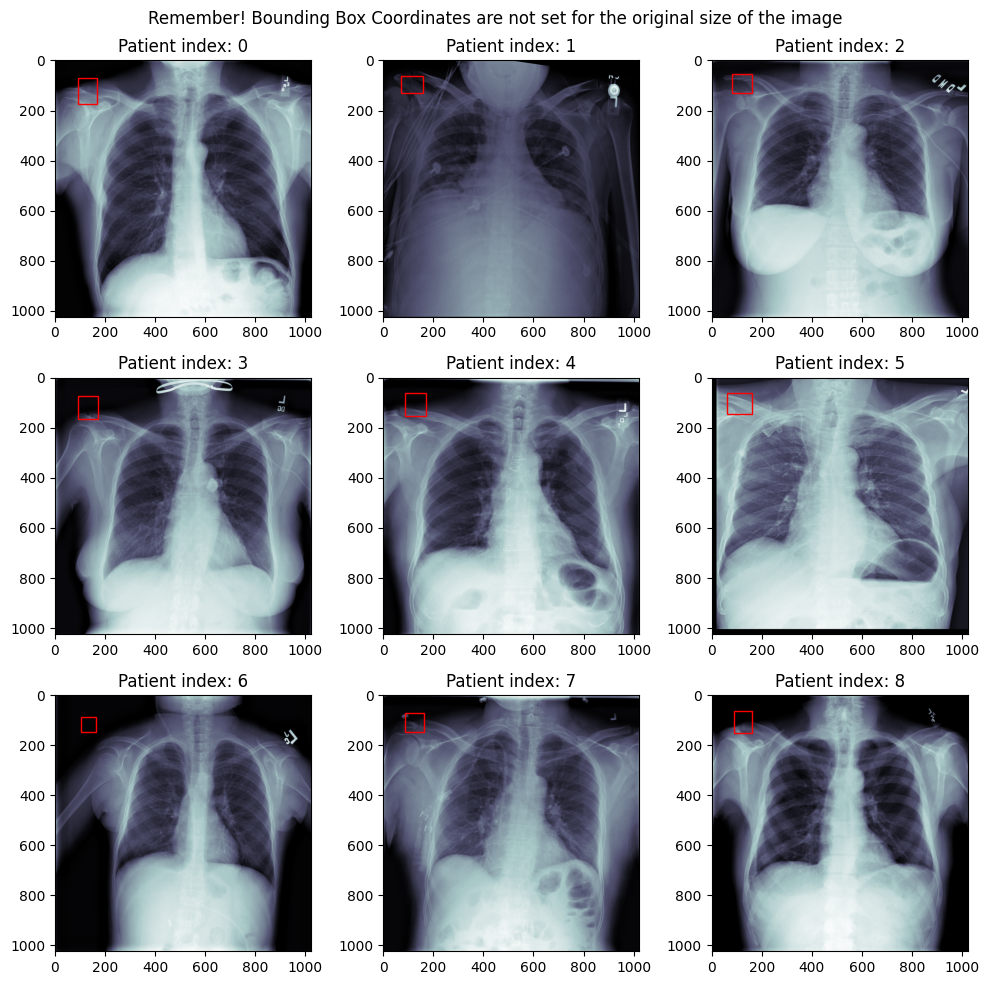

In [10]:
# Visualize training images and bounding box coordinates
fig, axs = plt.subplots(3, 3, figsize=(10, 10))
plt.suptitle('Remember! Bounding Box Coordinates are not set for the original size of the image')
c = 0

for i,j in itertools.product(range(3), range(3)):
    img = pydicom.dcmread(ROOT_PATH / f'{labels.name[c]}.dcm').pixel_array
    axs[i, j].imshow(img, cmap='bone')
    axs[i, j].axis('on')
    axs[i, j].set_title(f'Patient index: {c}')
    c += 1

    # Bounding Box
    for _, row in labels[labels.name == labels.name[c-1]].iterrows():
        rect = patches.Rectangle((row.x0, row.y0), row.w, row.h, edgecolor='r', facecolor='none')
        axs[i, j].add_patch(rect)

plt.tight_layout()
plt.savefig('F:/coding_projects/udemy_deep_learning_with_pytorch_medical_image_analysis/heart_detection_bbox_xray/Visualizations/raw_images_bbox.jpeg', dpi=300)
plt.show()

## Resize the images to scale with bounding boxes and save to Processed Directory


In [12]:
# Normalize indivual images instead of apply dataset wide normailzation
# for i, name in enumerate(tqdm(labels.name)):
#     dcm = pydicom.dcmread(ROOT_PATH / f'{name}.dcm').pixel_array
#     # Standardize the images
#     dcm = dcm / 255
#     # Resize the images
#     dcm_array = cv2.resize(dcm, (224, 224)).astype(np.float16) # Resize the images to 224x224

#     # Make directory and set train and validation split
#     train_or_val = "train" if i < 400 else "val"
#     current_save_path = SAVE_PATH / train_or_val
#     current_save_path.mkdir(parents=True, exist_ok=True)

#     # Normalize the images
#     dcm_array = (dcm_array - dcm_array.mean()) / dcm_array.std()

#     # Save the images
#     np.save(current_save_path / f'{name}.npy', dcm_array)

sums = 0
sums_squared = 0
train_ids = []
val_ids = []

for counter, patient_id in enumerate(list(labels.name)):  
    dcm_path = ROOT_PATH/patient_id  # Create the path to the dcm file
    dcm_path = dcm_path.with_suffix(".dcm")  # And add the .dcm suffix
    
    dcm = pydicom.dcmread(dcm_path)  # Read the dicom file with pydicom
    
     # Retrieve the actual image 
    dcm_array = dcm.pixel_array
    assert dcm_array.shape == (1024, 1024)
    
    # Resize the image to drastically improve training speed
    # In order to reduce the space when storing the image we convert it to float16
    # Standardize to 0-1 range
    dcm_array = (cv2.resize(dcm_array, (224, 224)) / 255).astype(np.float16)
            
    # 4/5 train split, 1/5 val split
    train_or_val = "train" if counter < 400 else "val" 
    
    # Add to corresponding train or validation patient index list
    if train_or_val == "train":
        train_ids.append(patient_id)
    else:
        val_ids.append(patient_id)
    
    current_save_path = SAVE_PATH/train_or_val # Define save path and create if necessary
    current_save_path.mkdir(parents=True, exist_ok=True)
    
    np.save(current_save_path/patient_id, dcm_array)  # Save the array in the corresponding directory
    
    normalizer = dcm_array.shape[0] * dcm_array.shape[1]  # Normalize sum of image
    if train_or_val == "train":  # Only use train data to compute dataset statistics
        sums += np.sum(dcm_array) / normalizer
        sums_squared += (np.power(dcm_array, 2).sum()) / normalizer


In [16]:
np.save("../DATA/05-Detection/Processed/train_subjects_det", train_ids)
np.save("../DATA/05-Detection/Processed/val_subjects_det", val_ids)

In [15]:
# Compute mean and std
mean = sums / len(train_ids)
std = np.sqrt(sums_squared / len(train_ids) - mean**2)
print(f'Mean: {mean}, Std: {std}')

Mean: 0.49462890625, Std: 0.2529296875


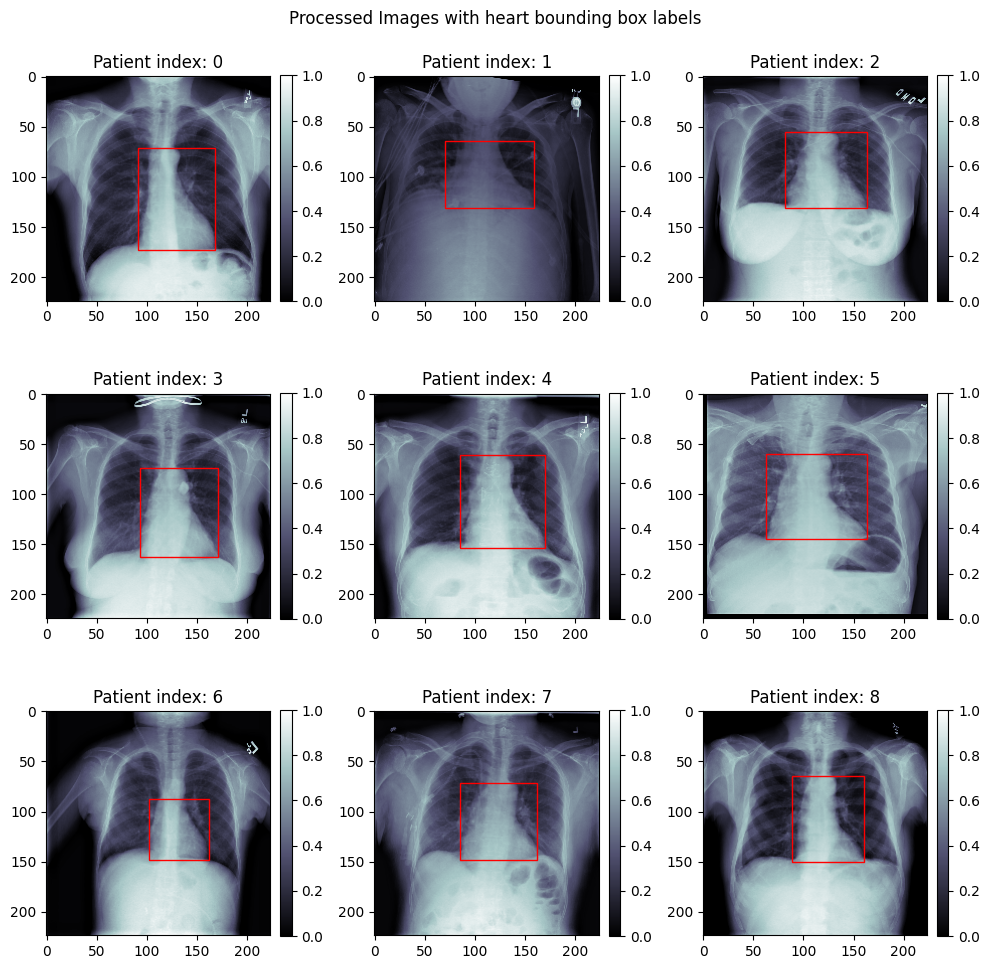

In [17]:
# Visualize processed images
fig, axs = plt.subplots(3, 3, figsize=(10, 10))
plt.suptitle('Processed Images with heart bounding box labels')
c = 0

for i,j in itertools.product(range(3), range(3)):
    img = np.load(SAVE_PATH / 'train' / f'{labels.name[c]}.npy')
    # axs[i, j].imshow(img, cmap='bone')
    axs[i, j].axis('on')
    axs[i, j].set_title(f'Patient index: {c}')
    c += 1

    # Set colorbar for each image
    # plt.colorbar(axs[i, j].imshow(img, cmap='bone'), )
    cbar = plt.colorbar(axs[i, j].imshow(img, alpha=1, cmap="bone", vmin=0, vmax=1), ax=axs[i, j], fraction=0.046, pad=0.04)

    # Plot bounding box
    for _, row in labels[labels.name == labels.name[c-1]].iterrows():
        rect = patches.Rectangle((row.x0 , row.y0 ), row.w , row.h , edgecolor='r', facecolor='none')
        axs[i, j].add_patch(rect)


plt.tight_layout()
plt.savefig('F:/coding_projects/udemy_deep_learning_with_pytorch_medical_image_analysis/heart_detection_bbox_xray/Visualizations/resized_standardized_xray_images_heart_bbox.jpeg', dpi=300)

# Data Augmentation

In [ ]:
# # indepth version of what the augmentation class does
# import torch
# from torchvision import transforms
# import numpy as np
# from torch.utils.data import Dataset
# import random
# import pandas as pd
# from pathlib import Path
# import matplotlib.pyplot as plt
# import matplotlib.patches as patches
# from PIL import Image
# import torchvision.transforms.functional as F


# class CardiacDataset(Dataset):
#     def __init__(self, path_to_labels_csv, patients, root_path, augs=None):
#         """
#         Args:
#             path_to_labels_csv (str): Path to CSV containing bounding box labels.
#             patients (str): Path to file containing patient identifiers.
#             root_path (str): Path to directory containing image data files.
#             augs (bool): Whether to apply augmentations.
#         """
#         self.labels = pd.read_csv(path_to_labels_csv)
#         self.patients = np.load(patients)
#         self.root_path = Path(root_path)
#         self.augment = augs

#         # Define the gamma contrast and affine transformations using torchvision
#         self.gamma_contrast = transforms.ColorJitter(brightness=0, contrast=0, saturation=0, hue=0.5)  # Gamma contrast is essentially changing brightness/contrast
#         self.affine_transform = transforms.RandomAffine(
#             degrees=(-10, 10),
#             translate=(0.1, 0.1),
#             scale=(0.8, 1.2)
#         )

#     def __len__(self):
#         """
#         Returns the length of the dataset (number of samples)
#         """
#         return len(self.patients)

#     def affine_transform_bbox(self, bbox, angle, translate, scale, img_width, img_height):
#         """
#         Apply affine transformation to the bounding box.
#         This includes scaling, translating, and rotating the bounding box.
#         """
#         x_min, y_min, x_max, y_max = bbox

#         # Apply translation
#         x_min += translate[0]  # Translate bounding box
#         y_min += translate[1]
#         x_max += translate[0]
#         y_max += translate[1]

#         # Apply scaling
#         x_min *= scale[0]
#         y_min *= scale[1]
#         x_max *= scale[0]
#         y_max *= scale[1]

#         # Rotation: only applies if the affine transform actually rotates
#         if angle != 0:
#             # Perform rotation on the center of the box
#             cx, cy = (x_min + x_max) / 2, (y_min + y_max) / 2
#             # Rotate coordinates (keeping in mind that we apply negative angle for counter-clockwise rotation)
#             angle_rad = np.deg2rad(angle)
#             cos_a = np.cos(angle_rad)
#             sin_a = np.sin(angle_rad)
#             dx_min = x_min - cx
#             dy_min = y_min - cy
#             dx_max = x_max - cx
#             dy_max = y_max - cy

#             x_min = cx + cos_a * dx_min - sin_a * dy_min
#             y_min = cy + sin_a * dx_min + cos_a * dy_min
#             x_max = cx + cos_a * dx_max - sin_a * dy_max
#             y_max = cy + sin_a * dx_max + cos_a * dy_max

#         # Ensure the bounding box is within the image size bounds
#         x_min = max(0, min(x_min, img_width))
#         y_min = max(0, min(y_min, img_height))
#         x_max = max(0, min(x_max, img_width))
#         y_max = max(0, min(y_max, img_height))

#         return [x_min, y_min, x_max, y_max]

#     def __getitem__(self, idx):
#         """
#         Returns an image paired with bbox around the heart.
#         """
#         patient = self.patients[idx]
#         # Get data according to index
#         data = self.labels[self.labels["name"] == patient]

#         # Get entries of the given patient
#         # Extract coordinates
#         x_min = data["x0"].item()
#         y_min = data["y0"].item()
#         x_max = x_min + data["w"].item()  # get xmax from width
#         y_max = y_min + data["h"].item()  # get ymax from height
#         bbox = [x_min, y_min, x_max, y_max]

#         # Load file and convert to tensor
#         file_path = self.root_path / patient  # Create the path to the file
#         img = np.load(f"{file_path}.npy").astype(np.float32)
#         img = torch.tensor(img).unsqueeze(0)  # Add channel dimension, make it a 4D tensor (C, H, W)

#         # Convert the tensor to a PIL Image for transformations
#         img_pil = Image.fromarray(img.squeeze().numpy())  # Remove channel dimension and convert to PIL image

#         # Get image dimensions for bounding box adjustment
#         img_height, img_width = img.shape[1], img.shape[2]

#         # Apply augmentations if specified
#         if self.augment:
#             # Apply gamma contrast (changing image brightness/contrast)
#             img_pil = self.gamma_contrast(img_pil)  # Apply gamma contrast to PIL image
            
#             # Apply affine transformations (rotation, translation, scaling)
#             img_pil = self.affine_transform(img_pil)  # Apply random affine transform to PIL image

#             # Apply affine transformation to bounding box
#             angle = random.uniform(-10, 10)
#             translate = (random.uniform(-0.1, 0.1), random.uniform(-0.1, 0.1))
#             scale = (random.uniform(0.8, 1.2), random.uniform(0.8, 1.2))
#             bbox = self.affine_transform_bbox(bbox, angle, translate, scale, img_width, img_height)

#         # Convert back to tensor after transformations
#         img = torch.tensor(np.array(img_pil)).unsqueeze(0)  # Convert PIL Image back to tensor and add channel dimension

#         # Normalize the image according to the values computed in preprocessing
#         img = (img - 0.494) / 0.252  # Normalize to the standard mean and std

#         return img, torch.tensor(bbox)


# dataset = CardiacDataset(
#     path_to_labels_csv="../DATA/05-Detection/rsna_heart_detection.csv",
#     patients="../DATA/05-Detection/Processed/train_subjects_det.npy",
#     root_path="../DATA/05-Detection/Processed/train",
#     augs=True
# )

# # Visualize the augmented images
# fig, axs = plt.subplots(3, 3, figsize=(10, 10))
# plt.suptitle('Augmented Images with heart bounding box labels')
# # randomly select images in the dataset
# random_idx = random.sample(range(len(dataset)), 9)

# for i, idx in enumerate(random_idx):
#     img, bbox = dataset[idx]
#     img = img.squeeze().numpy()
#     axs[i // 3, i % 3].imshow(img, cmap='bone')
#     axs[i // 3, i % 3].axis('on')
#     axs[i // 3, i % 3].set_title(f'Patient index: {idx}')

#     # Plot bounding box
#     rect = patches.Rectangle((bbox[0], bbox[1]), bbox[2] - bbox[0], bbox[3] - bbox[1], edgecolor='r', facecolor='none')
#     axs[i // 3, i % 3].add_patch(rect)

# plt.tight_layout()


In [25]:
import albumentations as A
import torch
from pathlib import Path
import pandas as pd
import numpy as np
from albumentations.pytorch import ToTensorV2

class CardiacDataset(torch.utils.data.Dataset):

    def __init__(self, path_to_labels_csv, patients, root_path, augs):
        self.labels = pd.read_csv(path_to_labels_csv)
        self.patients = np.load(patients)
        self.root_path = Path(root_path)
        self.augment = augs
        
    def  __len__(self):
        """
        Returns the length of the dataset
        """
        return len(self.patients)
        
    def __getitem__(self, idx):
        """
        Returns an image paired with bbox around the heart
        """
        patient = self.patients[idx]
        # Get data according to index
        data = self.labels[self.labels["name"] == patient]
        
        # Get entries of given patient
        # Extract coordinates
        x_min = data["x0"].item()
        y_min = data["y0"].item()
        x_max = x_min + data["w"].item()  # get xmax from width
        y_max = y_min + data["h"].item()  # get ymax from height
        bbox = [x_min, y_min, x_max, y_max]
        
        # Load file and convert to float32
        file_path = self.root_path / patient  # Create the path to the file
        img = np.load(f"{file_path}.npy").astype(np.float32)
        
        # Apply albumentations augmentations to image and bounding box
        if self.augment:
            # Convert bounding box to numpy array in format (num_bboxes, 4)
            bboxes = np.array([[bbox[0], bbox[1], bbox[2], bbox[3]]], dtype=np.float32)
            
            # Albumentations requires a dictionary format, including labels if needed
            transformed = self.augment(image=img, bboxes=bboxes)
            
            # Check if 'bboxes' is not empty before accessing
            if transformed['bboxes']:
                # Extract the transformed image and bounding box
                img = transformed['image']
                bbox = transformed['bboxes'][0]  # Since there is only one bbox
            else:
                # If no bounding boxes are returned, use the original bbox
                img = transformed['image']
                bbox = np.array([bbox], dtype=np.float32)
            
        # Normalize the image according to the values computed in Preprocessing
        img = (img - 0.494) / 0.252
        
        img = torch.tensor(img).unsqueeze(0)
        bbox = torch.tensor(bbox)
        
        return img, bbox


# Define the augmentation pipeline using albumentations
class AugmentationPipeline:
    def __init__(self):
        self.augment = A.Compose([
            A.RandomGamma(gamma_limit=(80, 120), p=1.0),  # Adjust Gamma using RandomGamma
            A.Affine(
                scale=(0.8, 1.2),  # Scale the image
                rotate=(-10, 10),   # Rotate by random angle between -10 and 10 degrees
                translate_percent={"x": (-0.1, 0.1), "y": (-0.1, 0.1)},  # Random translation
                p=1.0              # Apply this transformation with probability 1
            ),
            ToTensorV2()  # Convert to PyTorch tensor
        ])

    def get_augmenter(self):
        return self.augment

# Example usage
augmentation_pipeline = AugmentationPipeline()
augs = augmentation_pipeline.get_augmenter()


# Create the dataset
dataset = CardiacDataset(
    path_to_labels_csv="../DATA/05-Detection/rsna_heart_detection.csv",
    patients="../DATA/05-Detection/Processed/train_subjects_det.npy",
    root_path="../DATA/05-Detection/Processed/train",
    augs=augmentation_pipeline.get_augmenter()
)


In [26]:
dataset[0]

C:\Users\Myles McKay\AppData\Local\Temp\ipykernel_71896\462332123.py:51: DeprecationWarning: The truth value of an empty array is ambiguous. Returning False, but in future this will result in an error. Use `array.size > 0` to check that an array is not empty.
  if transformed['bboxes']:
C:\Users\Myles McKay\AppData\Local\Temp\ipykernel_71896\462332123.py:63: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  img = torch.tensor(img).unsqueeze(0)


(tensor([[[[-1.9603, -1.9603, -1.9603,  ..., -1.9603, -1.9603, -1.9603],
           [-1.9603, -1.9603, -1.9603,  ..., -1.9603, -1.9603, -1.9603],
           [-1.9603, -1.9603, -1.9603,  ..., -1.9391, -1.9159, -1.8645],
           ...,
           [-1.9603, -1.9603, -1.9603,  ...,  0.0029,  0.0869,  0.2088],
           [-1.9603, -1.9603, -1.9603,  ...,  0.0053,  0.1533,  0.2188],
           [-1.9603, -1.9603, -1.9603,  ...,  0.0438,  0.1714,  0.2239]]]]),
 tensor([[ 91.,  71., 168., 173.]]))

C:\Users\Myles McKay\AppData\Local\Temp\ipykernel_71896\462332123.py:51: DeprecationWarning: The truth value of an empty array is ambiguous. Returning False, but in future this will result in an error. Use `array.size > 0` to check that an array is not empty.
  if transformed['bboxes']:
C:\Users\Myles McKay\AppData\Local\Temp\ipykernel_71896\462332123.py:63: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  img = torch.tensor(img).unsqueeze(0)


torch.Size([1, 1, 224, 224])
tensor([[ 89.,  48., 155., 141.]])
torch.Size([1, 1, 224, 224])
tensor([[ 68.,  57., 168., 171.]])
torch.Size([1, 1, 224, 224])
tensor([[ 97.,  67., 178., 180.]])
torch.Size([1, 1, 224, 224])
tensor([[ 99.,  70., 171., 148.]])
torch.Size([1, 1, 224, 224])
tensor([[105.,  93., 193., 197.]])
torch.Size([1, 1, 224, 224])
tensor([[ 87.,  53., 170., 146.]])
torch.Size([1, 1, 224, 224])
tensor([[ 91.,  60., 174., 151.]])
torch.Size([1, 1, 224, 224])
tensor([[ 78.,  62., 176., 162.]])
torch.Size([1, 1, 224, 224])
tensor([[ 85.,  57., 161., 163.]])


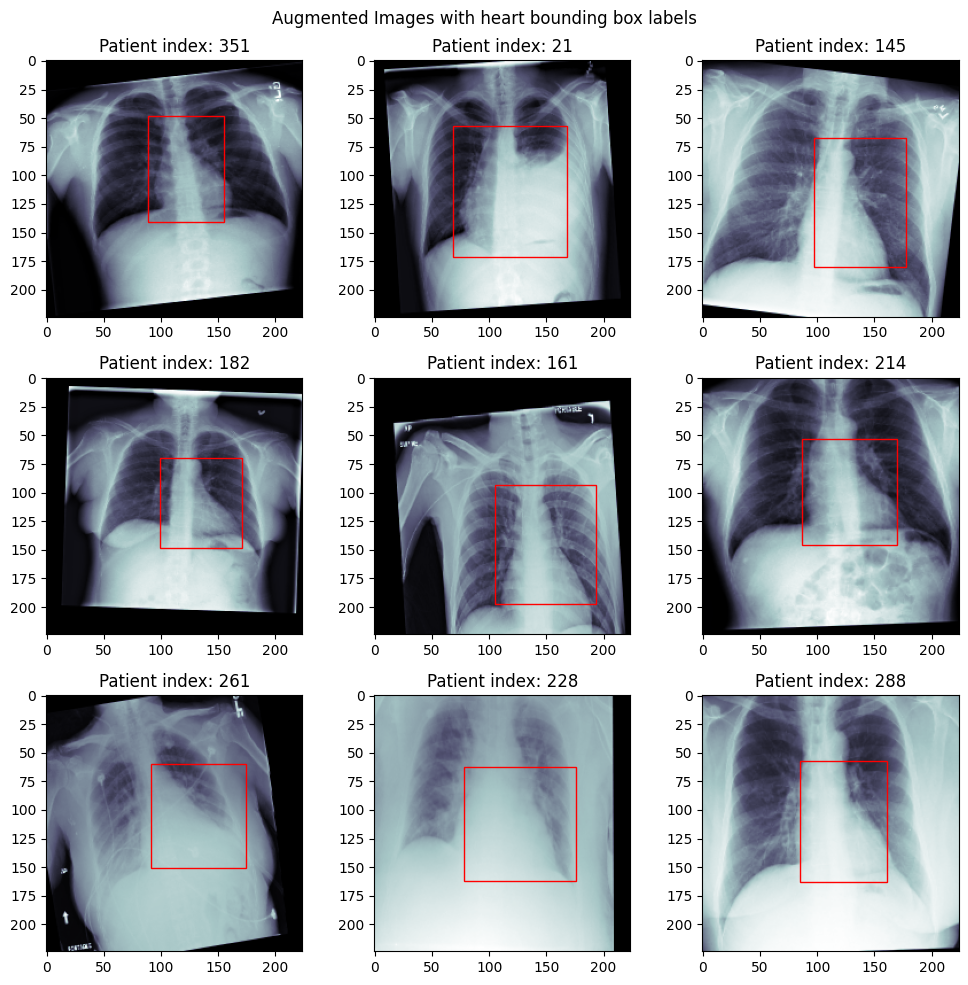

In [28]:
# Visualize the augmented images
fig, axs = plt.subplots(3, 3, figsize=(10, 10))
plt.suptitle('Augmented Images with heart bounding box labels')

# randomly select images in the dataset
random_idx = random.sample(range(len(dataset)), 9)

for i, idx in enumerate(random_idx):
    img, bbox = dataset[idx]
    print(img.shape)
    print(bbox)

    # Squeeze image to remove extra dimension and convert to numpy
    img = img.squeeze().numpy()

    # Convert bounding box to numpy and get the coordinates (bbox is now a 2D array with shape (1, 4))
    bbox = bbox.numpy()

    # Plot the image
    axs[i // 3, i % 3].imshow(img, cmap='bone')
    axs[i // 3, i % 3].axis('on')
    axs[i // 3, i % 3].set_title(f'Patient index: {idx}')

    # Extract the bounding box coordinates
    x_min, y_min, x_max, y_max = bbox[0]  # Access the first (and only) bbox

    # Plot bounding box (bbox format: [x_min, y_min, x_max, y_max])
    rect = patches.Rectangle((x_min, y_min), x_max - x_min, y_max - y_min, edgecolor='r', facecolor='none')
    axs[i // 3, i % 3].add_patch(rect)

plt.tight_layout()
plt.show()

In [ ]:
# def load_file(file_path):
#     return np.load(file_path).astype(np.float32)

In [ ]:
# train_transform = transforms.Compose([
#     transforms.ToTensor(), # Convert the image to tensor but should not undo the normalization from prior step
#     transforms.RandomAffine(degrees(-10,10), translate=(-10, 10), scale=(0.8, 1.2), )  


# ])